<a href="https://colab.research.google.com/github/beleja05/neuraldata_Amanda/blob/main/Coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amanda Belej
*Introduction to Neural Data Analysis*

**3/30/2026**

In [ ]:
#This cell imports numpy and matplot
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#This imports the data into numpy arrays
url_r1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
url_l1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
url_r2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'
url_l2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
spike_left_trial1 = np.loadtxt(url_l1, delimiter=',')
spike_right_trial1 = np.loadtxt(url_r1, delimiter=',')
spike_left_trial2 = np.loadtxt(url_l2, delimiter=',')
spike_right_trial2 = np.loadtxt(url_r2, delimiter=',')

In [ ]:
#This code prints the length of each of the arrays
print(len(spike_left_trial1))
print(len(spike_right_trial1))
print(len(spike_left_trial2))
print(len(spike_right_trial2))

65
45
53
69


In [ ]:
#This code calculates the firing rates of each dataset by taking the length and dividing it by the 30 second recording period
fr_left1 = len(spike_left_trial1)/30
fr_right1 = len(spike_right_trial1)/30
fr_left2 = len(spike_left_trial2)/30
fr_right2 = len(spike_right_trial2)/30
print(fr_left1)
print(fr_right1)
print(fr_left2)
print(fr_right2)

2.1666666666666665
1.5
1.7666666666666666
2.3


Do you think this neuron fires
more before left turn trials, or right turn trials?

It does not seem like there is a pattern of which cell fires more often as the left fired more in the first trial, but the right fire more in teh second trial.

/tmp/ipykernel_5002/3067005809.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(['Left Turn', 'Right Turn'])  # Label the y-ticks
/tmp/ipykernel_5002/3067005809.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(['Left Turn', 'Right Turn'])


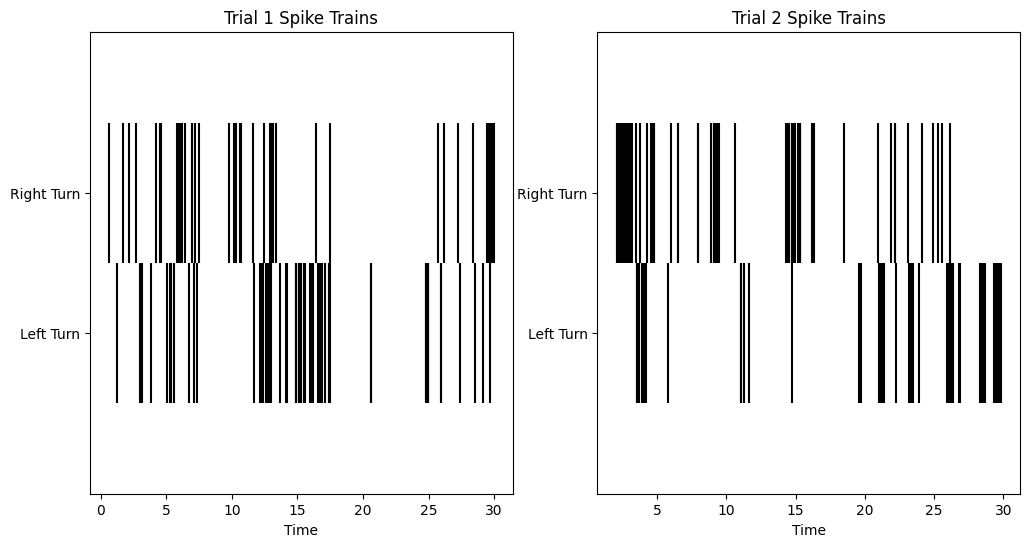

In [ ]:
#This cell makes two plots of spikes when the mouse is moving to the left and right. The left graph shows trial 1 and the other shows trial 2. The y-ticks place the right on top and the left on the bottom
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].eventplot([spike_left_trial1, spike_right_trial1], colors='black')
ax[0].set_title('Trial 1 Spike Trains')
ax[0].set_xlabel('Time')
ax[0].set_yticklabels(['Left Turn', 'Right Turn'])
ax[0].set_yticks([0, 1])

ax[1].eventplot([spike_left_trial2, spike_right_trial2], colors='black')
ax[1].set_title('Trial 2 Spike Trains')
ax[1].set_xlabel('Time')
ax[1].set_yticklabels(['Left Turn', 'Right Turn'])
ax[1].set_yticks([0, 1])

plt.show()

Does this neuron seem more "bursty", or more regular-firing, during left or right turn trials?

The graph shows some similar patterns of firing between trial 1 and trial 2 for each direction, but is not that consistant. It's not very clear, but I think in general the left turn neurons tend to be more bursty due to the perios between clusters of firing.

In [ ]:
#This cell calculates the ISI by using np.diff
ISI_left1 = np.diff(spike_left_trial1)
ISI_right1 = np.diff(spike_right_trial1)
ISI_left2 = np.diff(spike_left_trial2)
ISI_right2 = np.diff(spike_right_trial2)
print(ISI_left1)
print(ISI_right1)
print(ISI_left2)
print(ISI_right2)


[1.75574  0.057416 0.044268 0.682444 1.233286 0.22358  0.06531  0.020767
 0.279245 1.098578 0.356628 0.259738 4.367309 0.45441  0.136212 0.041073
 0.250092 0.194642 0.013271 0.017694 0.039383 0.025559 0.039875 0.087183
 0.669328 0.444426 0.08617  0.658759 0.04267  0.010568 0.177039 0.049183
 0.042947 0.012103 0.027157 0.009953 0.033915 0.199219 0.080671 0.417423
 0.138916 0.056955 0.423076 0.139837 0.031519 0.032256 0.116337 0.190494
 0.304743 0.038922 0.025313 3.139308 0.007495 4.216013 0.005683 0.099533
 0.047585 0.011305 0.951061 0.031273 1.420155 1.117563 0.621803 0.521933]
[1.071575 0.437729 0.5137   1.515878 0.318198 0.107274 1.187543 0.147978
 0.03453  0.036249 0.140145 0.267233 0.52307  0.017264 0.220201 0.274975
 2.316257 0.35027  0.109701 0.081101 0.331192 0.067676 0.921938 0.82388
 0.445808 0.0384   0.204442 0.191201 3.087207 1.011824 8.252683 0.445009
 1.067244 1.168435 1.104384 0.025774 0.115845 0.045742 0.038646 0.089242
 0.017357 0.02433  0.023992 0.093881]
[0.009524 0.0

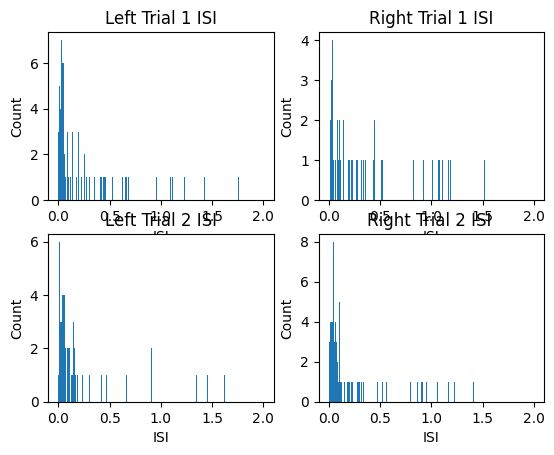

In [ ]:
#This cell makes 4 plots which shows histograms of each direction for both trials. The bins make it so the ISI range is between 0 and 2 and each bin is 0.1 apart.
fig, axs = plt.subplots(2, 2)
bins = np.arange(0, 2.01, 0.01)

axs[0, 0].hist(ISI_left1, bins=bins)
axs[0, 0].set_title('Left Trial 1 ISI')
axs[0, 0].set_xlabel('ISI')
axs[0, 0].set_ylabel('Count')

axs[0, 1].hist(ISI_right1, bins=bins)
axs[0, 1].set_title('Right Trial 1 ISI')
axs[0, 1].set_xlabel('ISI')
axs[0, 1].set_ylabel('Count')

axs[1, 0].hist(ISI_left2, bins=bins)
axs[1, 0].set_title('Left Trial 2 ISI')
axs[1, 0].set_xlabel('ISI')
axs[1, 0].set_ylabel('Count')

axs[1, 1].hist(ISI_right2, bins=bins)
axs[1, 1].set_title('Right Trial 2 ISI ')
axs[1, 1].set_xlabel('ISI')
axs[1, 1].set_ylabel('Count')

plt.show()

Does this neuron tend to fire in "bursts"? Does it have higher "burstiness" during left or right turn trials?

This neuron seems relatively bursty as evidenced by the high count of ISI in the low range. It seems like the neuron is more bursty in the left direction, but it's not by a large margin.


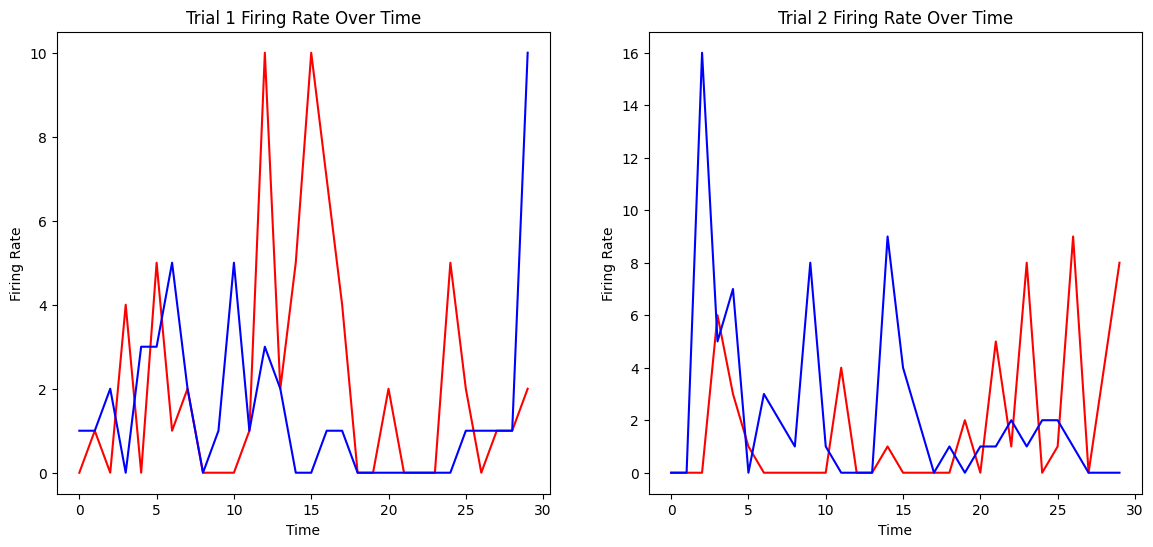

In [ ]:
#This cell makes two plots that plots the firing rate over time for each trial. Left is in red and right is in blue. The firing rate calculation puts the number of spikes into bins over the 30 second recording period where each bin is 1 second.
bin_edges = np.arange(0, 31, 1)

fr_left1_bin, _ = np.histogram(spike_left_trial1, bins=bin_edges)
fr_right1_bin, _ = np.histogram(spike_right_trial1, bins=bin_edges)
fr_left2_bin, _ = np.histogram(spike_left_trial2, bins=bin_edges)
fr_right2_bin, _ = np.histogram(spike_right_trial2, bins=bin_edges)

time_points = np.arange(0, 30, 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].plot(time_points, fr_left1_bin, label='Left Turn Trial 1', color='red')
axs[0].plot(time_points, fr_right1_bin, label='Right Turn Trial 1', color='blue')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Firing Rate')
axs[0].set_title('Trial 1 Firing Rate Over Time')

axs[1].plot(time_points, fr_left2_bin, label='Left Turn Trial 2', color='red')
axs[1].plot(time_points, fr_right2_bin, label='Right Turn Trial 2', color='blue')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Firing Rate')
axs[1].set_title('Trial 2 Firing Rate Over Time')

plt.show()

Does the firing rate between left and right turn trials differ at specific timepoints during the 30 s waiting period? Is the pattern different for trial 1 and trial 2?

The patterns between trail 1 and 2 are very different. First of all, in trial one theres the largest firing rate during the left side at ~11 to 17 seconds where the right is firing a bit at the beginning, goes silent, then has a huge burst at the end. In contrast, trial 2 has the left firing rate occuring throughout, but mostly between 20 to 30 seconds. The right firing rate is huge at ~3 seconds  and continues to fire on and off until ~17 seconds and then is very low for the rest of the recording.